### Chapter-5

**5.1** We now review $k$-fold cross-validation.
_(a) Explain how $k$-fold cross-validation is implemented._
* **Answer:** Divide the dataset into k equal-sized subsets. Hold out one subset as validation set and use the remaining k-1 folds as training set. Train model on the training folds and evaluate the model on the held-out fold to obtain a validation score. Repeat this process for k times, each time using a different fold as validation and remaining as training set. After all k iterations are completed, average the k validation scores to produce final cross-validation estimate of the model's performance.

_(b) What are the advantages and disadvantages of $k$-fold crossvalidation relative to:_
  _* i. The validation set approach?_
  _* ii. LOOCV?_

* **Answer:** The advantage compared to validation set approach is that the k-fold cross-validation uses the entire data set for both training and validation instead of one single split, and average the estimated scores over k splits rather one score, so the result has less bias and more reliable. The disadvantage is higher computational cost. Also, validation set approach has lower variance and develops a model that generalizes to unseen data better. The advantage compared to LOOCV is lower variance since the LOOCV training sets have large overlaps with each other and almost trained on the whole data every time, so LOOCV result face higher risk of overfit. Also k-fold cross-validation has lower computational cost. LOOCV uses almost the entire dataset for training in each iteration (n − 1 observations), so it may have slightly lower bias in estimating test error compared to k-fold cross-validation

**5.2** In Chapter 4, we used logistic regression to predict the probability of default using income and balance on the Default data set. We will now estimate the test error of this logistic regression model using the validation set approach. Do not forget to set a random seed before beginning your analysis.

* (a) Fit a logistic regression model that uses income and balance to predict default.
* (b) Using the validation set approach, estimate the test error of this model. In order to do this, you must perform the following steps:
  * i. Split the sample set into a training set and a validation set.
  * ii. Fit a multiple logistic regression model using only the training observations.
  * iii. Obtain a prediction of default status for each individual in the validation set by computing the posterior probability of default for that individual, and classifying the individual to the default category if the posterior probability is greater than 0.5 .
  * iv. Compute the validation set error, which is the fraction of the observations in the validation set that are misclassified.


In [ ]:
from ISLP import load_data
# load data
Default = load_data("Default")
Default.head()

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138947
3,No,No,529.250605,35704.493935
4,No,No,785.655883,38463.495879


In [ ]:
# train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
  Default[['income','balance']], Default['default'].map({'No':0, 'Yes':1}), test_size=0.5, random_state=1
)

# fit a logistic model
import statsmodels.api as sm

X_train_sm = sm.add_constant(X_train) # add constant
logit_model = sm.Logit(y_train, X_train_sm)
logit_model_result = logit_model.fit()
logit_model_result.summary() # model summary

Optimization terminated successfully.
         Current function value: 0.079028
         Iterations 10


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                default   No. Observations:                 5000
Model:                          Logit   Df Residuals:                     4997
Method:                           MLE   Df Model:                            2
Date:                Thu, 05 Mar 2026   Pseudo R-squ.:                  0.4768
Time:                        19:30:43   Log-Likelihood:                -395.14
converged:                       True   LL-Null:                       -755.25
Covariance Type:            nonrobust   LLR p-value:                4.024e-157
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -11.6342      0.620    -18.763      0.000     -12.850     -10.419
income      1.635e-05   7.15e-06      2.287      0.022    2.34e-06    3.04e-05
balance        0.0058      0.000     17.791      0.000       0.005       0.006
==============================================================================

Possibly complete quasi-separation: A fraction 0.16 of observations can be
perfectly predicted. This might indicate that there is complete
quasi-separation. In this case some parameters will not be identified.
"""

In [ ]:
# make predictions using the logistic model
X_test_sm = sm.add_constant(X_test) # add constant
logit_pred_prob = logit_model_result.predict(X_test_sm)
logit_pred = (logit_pred_prob>0.5).astype(int) # convert to 1 or 0
logit_validation_error = (logit_pred != y_test).mean() # calculate validation error
print('The validation error of the logistic model is:', logit_validation_error)

The validation error of the logistic model is: 0.025


* (c) Repeat the process in (b) three times, using three different splits of the observations into a training set and a validation set. Comment on the results obtained.


In [ ]:
val_errors = []
for seed in [1,12,123]:
  # split into training and validation
  X_train, X_test, y_train, y_test = train_test_split(
    Default[['balance','income']], Default['default'].map({'Yes':1, 'No':0}), test_size=0.5, random_state=seed
  )

  # add constant
  X_train_sm = sm.add_constant(X_train)
  X_test_sm = sm.add_constant(X_test)

  # fit logistic model
  logit_model = sm.Logit(y_train, X_train_sm)
  logit_model_result = logit_model.fit()

  # make predictions
  logit_pred_prob = logit_model_result.predict(X_test_sm)
  logit_pred = (logit_pred_prob>0.5).astype(int) # convert to 1 or 0
  logit_validation_error = (logit_pred != y_test).mean() # calculate validation error

  val_errors.append(logit_validation_error)

# print the validation errors
for i, j in enumerate(val_errors):
    print(f"Split {i+1} validation error: {j:.4f}")

Optimization terminated successfully.
         Current function value: 0.079028
         Iterations 10
Optimization terminated successfully.
         Current function value: 0.077996
         Iterations 10
Optimization terminated successfully.
         Current function value: 0.083269
         Iterations 10
Split 1 validation error: 0.0250
Split 2 validation error: 0.0270
Split 3 validation error: 0.0256


**comment:** The validation errors of three splits are similar to each other, indicating stable model performance

* (d) Now consider a logistic regression model that predicts the probability of default using income, balance, and a dummy variable for student. Estimate the test error for this model using the validation set approach. Comment on whether or not including a dummy variable for student leads to a reduction in the test error rate.

In [ ]:
# create student dummy variable
Default['student_dummy'] = Default['student'].map({'Yes':1, 'No':0})

# split train test
X_train, X_test, y_train, y_test = train_test_split(Default[['student_dummy','balance','income']],
                                                    Default['default'].map({'Yes':1, 'No':0}), test_size=0.5, random_state=seed)
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

# fit logistic model
logit_model = sm.Logit(y_train, X_train)
logit_model_result = logit_model.fit()

# predictions
logit_model_pred_prob = logit_model_result.predict(X_test)
logit_model_pred = (logit_model_pred_prob>0.5).astype(int)

# validation error
validation_error = (logit_model_pred != y_test).mean()

# print result
print('The validation error of model adding dummy variable student is:', validation_error)

Optimization terminated successfully.
         Current function value: 0.130614
         Iterations 9
The validation error of model adding dummy variable student is: 0.0366


**Comment:** The prediction result shows that NOT adding student dummy variable leads to reduction in the test error.

**5.3** We will now perform cross-validation on a simulated data set.
* (a) Generate a simulated data set as follows:


In [ ]:
import numpy as np
rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)

In this data set, what is $n$ and what is $p$ ? Write out the model used to generate the data in equation form.

**Answer:** 
n is 100. p is 1
the model used to generate the data in equation form is:
$$
y_i = x_i - 2 x_i^2 + \epsilon_i, \quad i = 1, \dots, 100
$$

* (b) Create a scatterplot of $X$ against $Y$. Comment on what you find.


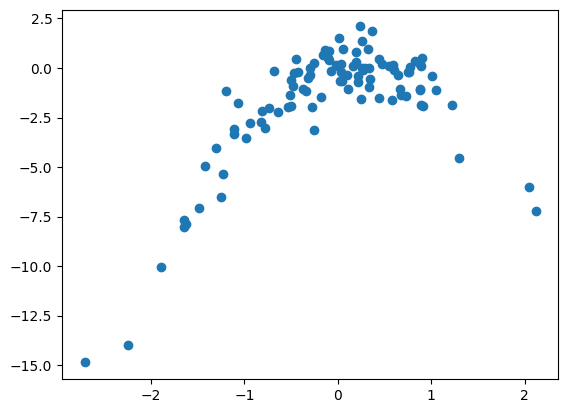

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(x, y)

**Comment:** The relationship between x and y is non-linear. Most of the x values are between -1 and 1, and most of y values are between -2 and 2. When x<0, as x increases, y increases. When x>0, as x increases, y decreases

* (c) Set a random seed, and then compute the LOOCV errors that result from fitting the following four models using least squares:
  * i. $Y=\beta_0+\beta_1 X+\epsilon$
  * ii. $Y=\beta_0+\beta_1 X+\beta_2 X^2+\epsilon$
  * iii. $Y=\beta_0+\beta_1 X+\beta_2 X^2+\beta_3 X^3+\epsilon$
  * iv. $Y=\beta_0+\beta_1 X+\beta_2 X^2+\beta_3 X^3+\beta_4 X^4+\epsilon$.

Note you may find it helpful to use the data.frame() function to create a single data set containing both $X$ and $Y$.


In [ ]:
# create a DataFrame with all polynomial x and y
import pandas as pd

df = pd.DataFrame({
    'X1': x,
    'X2': x**2,
    'X3': x**3,
    'X4': x**4,
    'Y': y
})

df.head()

,X1,X2,X3,X4,Y
0,0.345584,0.119428,0.041273,0.014263,-0.544554
1,0.821618,0.675056,0.554639,0.455701,0.333950
2,0.330437,0.109189,0.036080,0.011922,-0.013532
3,-1.303157,1.698219,-2.213046,2.883947,-4.030442
4,0.905356,0.819669,0.742092,0.671858,0.484861


In [ ]:
from sklearn.model_selection import LeaveOneOut
from sklearn.linear_model import LinearRegression

In [ ]:
# use LOO fit model1
np.random.seed(1) # set random seed
loo = LeaveOneOut()
model1_mse = []

for train_folds, val_folds in loo.split(x):

    # split model to tain and test using LOO
    X_train = df[['X1']].iloc[train_folds]
    X_test = df[['X1']].iloc[val_folds]
    y_train = df['Y'][train_folds]
    y_test = df['Y'][val_folds]

    # fit linear regression model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # get model results
    y_pred = model.predict(X_test)

    # calculate mse
    model1_mse.append((y_test.values - y_pred)**2)

loo_error_model1 = np.mean(model1_mse)
print("Model 1 LOO MSE:", loo_error_model1)

Model 1 LOO MSE: 6.633029839181983


In [ ]:
# use LOO fit model2
np.random.seed(1) # set random seed
loo = LeaveOneOut()
model2_mse = []

for train_folds, val_folds in loo.split(x):

    # split model to tain and test using LOO
    X_train = df[['X1','X2']].iloc[train_folds]
    X_test = df[['X1','X2']].iloc[val_folds]
    y_train = df['Y'][train_folds]
    y_test = df['Y'][val_folds]

    # fit linear regression model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # get model results
    y_pred = model.predict(X_test)

    # calculate mse
    model2_mse.append((y_test.values - y_pred)**2)

loo_error_model2 = np.mean(model2_mse)
print("Model 2 LOO MSE:", loo_error_model2)

Model 2 LOO MSE: 1.1229368563419684


In [ ]:
# use LOO fit model3
np.random.seed(1) # set random seed
loo = LeaveOneOut()
model3_mse = []

for train_folds, val_folds in loo.split(x):

    # split model to tain and test using LOO
    X_train = df[['X1','X2','X3']].iloc[train_folds]
    X_test = df[['X1','X2','X3']].iloc[val_folds]
    y_train = df['Y'][train_folds]
    y_test = df['Y'][val_folds]

    # fit linear regression model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # get model results
    y_pred = model.predict(X_test)

    # calculate mse
    model3_mse.append((y_test.values - y_pred)**2)

loo_error_model3 = np.mean(model3_mse)
print("Model 3 LOO MSE:", loo_error_model3)

Model 3 LOO MSE: 1.301796548935888


In [ ]:
# use LOO fit model4
np.random.seed(1) # set random seed
loo = LeaveOneOut()
model4_mse = []

for train_folds, val_folds in loo.split(x):

    # split model to tain and test using LOO
    X_train = df[['X1','X2','X3','X4']].iloc[train_folds]
    X_test = df[['X1','X2','X3','X4']].iloc[val_folds]
    y_train = df['Y'][train_folds]
    y_test = df['Y'][val_folds]

    # fit linear regression model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # get model results
    y_pred = model.predict(X_test)

    # calculate mse
    model4_mse.append((y_test.values - y_pred)**2)

loo_error_model4 = np.mean(model4_mse)
print("Model 4 LOO MSE:", loo_error_model4)

Model 4 LOO MSE: 1.332394269417934


* (d) Repeat (c) using another random seed, and report your results. Are your results the same as what you got in (c)? Why?


In [ ]:
# rerun three models with different random seed

np.random.seed(123) # set random seed
loo = LeaveOneOut()

# create a list to store the LOO MSE results
model_mse = [[] for _ in range(4)]

# create a vector to store variables used in the four models
var_list = [['X1'],['X1','X2'],['X1','X2','X3'],['X1','X2','X3','X4']]

# loop through each model
for i, v in enumerate(var_list):

  # split model to tain and test using LOO
  for train_folds, val_folds in loo.split(df):

      X_train = df[v].iloc[train_folds]
      X_test = df[v].iloc[val_folds]
      y_train = df['Y'][train_folds]
      y_test = df['Y'][val_folds]

      # fit linear regression model
      model = LinearRegression()
      model.fit(X_train, y_train)

      # get model results
      y_pred = model.predict(X_test)

      # calculate mse
      model_mse[i].append((y_test.values - y_pred)**2)

  print(f"Model {i+1} LOO MSE:", np.mean(model_mse[i]))

Model 1 LOO MSE: 6.633029839181983
Model 2 LOO MSE: 1.1229368563419684
Model 3 LOO MSE: 1.301796548935888
Model 4 LOO MSE: 1.332394269417934


**Comment:** The result is same as what I got in (c)

* (e) Which of the models in (c) had the smallest LOOCV error? Is this what you expected? Explain your answer.


**Answer:** The second model $Y=\beta_0+\beta_1 X+\beta_2 X^2+\epsilon$ has the smallest LOOCV error. This is expected because the model function aligns with the function used to generate the data x and y


* (f) Comment on the statistical significance of the coefficient estimates that results from fitting each of the models in (c) using least squares. Do these results agree with the conclusions drawn based on the cross-validation results?


In [ ]:
import statsmodels.api as sm

# model1
X1 = sm.add_constant(df[['X1']])
model1 = sm.OLS(df['Y'], X1).fit()
print('The significance of the model1 x coefficient is:', model1.pvalues.iloc[1],'\n')

# model 2
X2 = sm.add_constant(df[['X1','X2']])
model2 = sm.OLS(df['Y'], X2).fit()
print('The significance of the model2 x coefficient is:', model2.pvalues.iloc[1])
print('The significance of the model2 x^2 coefficient is:', model2.pvalues.iloc[2],'\n')

# model 3
X3 = sm.add_constant(df[['X1','X2','X3']])
model3 = sm.OLS(df['Y'], X3).fit()
print('The significance of the model3 x coefficient is:', model3.pvalues.iloc[1])
print('The significance of the model3 x^2 coefficient is:', model3.pvalues.iloc[2])
print('The significance of the model3 x^3 coefficient is:', model3.pvalues.iloc[3],'\n')

# model 3
X4 = sm.add_constant(df[['X1','X2','X3','X4']])
model4 = sm.OLS(df['Y'], X4).fit()
print('The significance of the model4 x coefficient is:', model4.pvalues.iloc[1])
print('The significance of the model4 x^2 coefficient is:', model4.pvalues.iloc[2])
print('The significance of the model4 x^3 coefficient is:', model4.pvalues.iloc[3])
print('The significance of the model4 x^4 coefficient is:', model4.pvalues.iloc[4])

The significance of the model1 x coefficient is: 1.0365062391097462e-09 

The significance of the model2 x coefficient is: 1.4949127104685944e-11
The significance of the model2 x^2 coefficient is: 1.3400677700015243e-39 

The significance of the model3 x coefficient is: 4.4485155714979535e-08
The significance of the model3 x^2 coefficient is: 3.968905542529493e-37
The significance of the model3 x^3 coefficient is: 0.28720183125006776 

The significance of the model4 x coefficient is: 2.5912962860712868e-05
The significance of the model4 x^2 coefficient is: 2.3960259344287474e-19
The significance of the model4 x^3 coefficient is: 0.6424909798530241
The significance of the model4 x^4 coefficient is: 0.02310661043617233


**Comment:** The OLS results above show that the coefficients of x and x^2 are significant, yet the coefficidents of x^3 and x^4 are not significant (although x^4 coefficient is small enough to be lower than 0.05, but it is less relevant as it is much higher than the significance levels of x and x^2). This result lines up with the cross validation.

### Chapter-6

**6.1** It is well-known that ridge regression tends to give similar coefficient values to correlated variables, whereas the lasso may give quite different coefficient values to correlated variables. We will now explore this property in a very simple setting.

Suppose that $n=2, p=2, x_{11}=x_{12}, x_{21}=x_{22}$. Furthermore, suppose that $y_1+y_2=0$ and $x_{11}+x_{21}=0$ and $x_{12}+x_{22}=0$, so that the estimate for the intercept in a least squares, ridge regression, or lasso model is zero: $\hat{\beta}_0=0$.
* (a) Write out the ridge regression optimization problem in this setting.


Answer:
Function: 
$$
y_i = \beta_0 + \beta_1 x_{i1} + \beta_2 x_{i2}
$$

The Ridge optmization function:
$$
\min_{\beta_0,\beta_1,\beta_2}
\sum_{i=1}^{n}(y_i - (\beta_0 + \beta_1 x_{i1} + \beta_2 x_{i2}))^2
+ \lambda(\beta_1^2 + \beta_2^2)
$$

$$\Downarrow $$

$$
\min_{\beta_0,\beta_1,\beta_2}
\sum_{i=1}^{n}(y_i - \beta_0 - \beta_1 x_{i1} - \beta_2 x_{i2})^2
+ \lambda(\beta_1^2 + \beta_2^2)
$$

$$\Downarrow $$

$$
\min_{\beta_0,\beta_1,\beta_2}
\sum_{i=1}^{n}\left[(y_1 - \beta_0 - \beta_1 x_{11} - \beta_2 x_{12})^2+(y_2 - \beta_0 - \beta_2 x_{21} - \beta_2 x_{22})^2\right]
+ \lambda(\beta_1^2 + \beta_2^2)
$$

Given:

- n = 2
- \(x_{11} = x_{12}\)
- \(x_{21} = x_{22}\)
- \(y_1 + y_2 = 0\)
- \(x_{11} + x_{21} = 0\)
- \(x_{12} + x_{22} = 0\)
- $\hat{\beta}_0 = 0$

The above Ridge transformed regression optimization function becomes:

$$
\min_{\beta_1,\beta_2}
\left[
(y_1 - \beta_1 x_{11} - \beta_2 x_{11})^2
+
(y_2 - \beta_1 x_{21} - \beta_2 x_{21})^2
\right]
+
\lambda(\beta_1^2 + \beta_2^2)
$$

$$\Downarrow $$

$$
\min_{\beta_1,\beta_2}
\left[
(y_1 - (\beta_1+\beta_2)x_{11})^2
+
(y_2 - (\beta_1+\beta_2)x_{21})^2
\right]
+
\lambda(\beta_1^2+\beta_2^2).
$$

* (b) Argue that in this setting, the ridge coefficient estimates satisfy $\hat{\beta}_1=\hat{\beta}_2$.


Answer:

From part (a), the Ridge penalty depends on

$$
\lambda(\beta_1^2+\beta_2^2).
$$

For any two numbers that add up to the same total. The sum of their squares is smallest when the numbers are equal. So
$$
\lambda(\beta_1^2+\beta_2^2).
$$ 
is minimized when

$$
\beta_1=\beta_2
$$

Therefore, the ridge estimates must satisfy

$$
\hat{\beta}_1=\hat{\beta}_2.
$$

* (c) Write out the lasso optimization problem in this setting.

Answer:

Function: 
$$
y_i = \beta_0 + \beta_1 x_{i1} + \beta_2 x_{i2}
$$

The lasso optimization function:

$$
\min_{\beta_0,\beta_1,\beta_2}
\sum_{i=1}^{n} (y_i - \beta_0 - \beta_1 x_{i1} - \beta_2 x_{i2})^2
+ \lambda (|\beta_1| + |\beta_2|)
$$

Given:

- \(n = 2\)
- \(x_{11} = x_{12}\)
- \(x_{21} = x_{22}\)
- $\hat{\beta}_0 = 0$
Lasso optimization problem in this setting becomes

$$
\min_{\beta_1,\beta_2}
\left[
(y_1 - (\beta_1+\beta_2)x_{11})^2 +
(y_2 - (\beta_1+\beta_2)x_{21})^2
\right]
+ \lambda (|\beta_1| + |\beta_2|)
$$

* (d) Argue that in this setting, the lasso coefficients $\hat{\beta}_1$ and $\hat{\beta}_2$ are not unique - in other words, there are many possible solutions to the optimization problem in (c). Describe these solutions.


Answer:

However, the lasso penalty is

$$
\lambda(|\beta_1| + |\beta_2|).
$$

There are many ways to split beta_1, beta_2 that produce ths same fitted values.
All of these give the same fitted values.
Therefore the optimization problem has many possible solutions

**6.2** In this exercise, we will generate simulated data, and will then use this data to perform forward and backward stepwise selection.

* (a) Create a random number generator and use its normal() method to generate a predictor $X$ of length $n=100$, as well as a noise vector $\epsilon$ of length $n=100$.

In [ ]:
set.seed(1)  # set seed

# generate predictor X and noise epsilon
X = rnorm(100)
e = rnorm(100)

* (b) Generate a response vector $Y$ of length $n=100$ according to the model, where $\beta_0, \beta_1, \beta_2$, and $\beta_3$ are constants of your choice.

$$
Y=\beta_0+\beta_1 X+\beta_2 X^2+\beta_3 X^3+\epsilon
$$

In [ ]:
set.seed(12)  # set seed

# generate constants
beta0 = runif(1, -5, 5)
beta1 = runif(1, -10, 10)
beta2 = runif(1, -10, 10)
beta3 = runif(1, -10, 10)

print(paste('beta0=',beta0))
print(paste('beta1=',beta1))
print(paste('beta2=',beta2))
print(paste('beta3=',beta3))
# generate response Y
Y = beta0 + beta1*X + beta2*X^2 + beta3*X^3 + e

[1] "beta0= -4.30639084195718"
[1] "beta1= 6.35550397448242"
[1] "beta2= 8.85243464726955"
[1] "beta3= -4.61236247327179"


In [ ]:
# create a data frame with predictors fro X to X^10
data <- data.frame(Y = Y)
for (i in 1:10) {
  data[[paste0("X", i)]] = X^i
}
head(data)

,Y,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,-4.3001576,-0.6264538,0.39244438,-0.245848275,0.154012589,-0.0964817733,6.044137e-02,-3.786373e-02,2.371988e-02,-1.485941e-02,9.308733e-03
2,-2.8271478,0.1836433,0.03372487,0.006193347,0.001137367,0.0002088698,3.835755e-05,7.044108e-06,1.293603e-06,2.375616e-07,4.362661e-08
3,-1.6554105,-0.8356286,0.69827518,-0.583498718,0.487588224,-0.4074426711,3.404708e-01,-2.845071e-01,2.377423e-01,-1.986642e-01,1.660095e-01
4,9.7936354,1.5952808,2.54492084,4.059863355,6.476622070,10.3320308510,1.648249e+01,2.629420e+01,4.194663e+01,6.691666e+01,1.067509e+02
5,-2.0706450,0.3295078,0.10857537,0.035776429,0.011788611,0.0038844391,1.279953e-03,4.217544e-04,1.389714e-04,4.579214e-05,1.508887e-05
6,0.7530548,-0.8204684,0.67316837,-0.552313364,0.453155653,-0.3717998868,3.050501e-01,-2.502839e-01,2.053500e-01,-1.684832e-01,1.382352e-01


* (c) Use forward stepwise selection in order to select a model containing the predictors $X, X^2, \ldots, X^{10}$. What is the model obtained according to $C_p$ ? Report the coefficients of the model obtained.


In [ ]:
library(leaps)
# forward stepwise selection
forward_model = regsubsets(Y ~ X1+X2+X3+X4+X5+X6+X7+X8+X9+X10,
                          data = data,
                          nvmax=10,
                          method='forward')

# show model summary
forward_model_summary = summary(forward_model)

# show selected predictors in each model
print('The model result summary is:')
forward_model_summary$which

# model index with the smallest Cp
best_cp_index = which.min(forward_model_summary$cp)

# show the model obtained according to best cp
best_predictors = names(which(forward_model_summary$which[best_cp_index, ]))
print(paste(
  'The predictors obtained according to best cp:',
  paste(names(which(forward_model_summary$which[best_cp_index, ])), collapse = ", ")
))

[1] "The model result summary is:"


,(Intercept),X1,X2,X3,X4,X5,X6,X7,X8,X9,X10
1,TRUE,FALSE,TRUE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE
2,TRUE,FALSE,TRUE,FALSE,FALSE,TRUE,FALSE,FALSE,FALSE,FALSE,FALSE
3,TRUE,TRUE,TRUE,FALSE,FALSE,TRUE,FALSE,FALSE,FALSE,FALSE,FALSE
4,TRUE,TRUE,TRUE,TRUE,FALSE,TRUE,FALSE,FALSE,FALSE,FALSE,FALSE
5,TRUE,TRUE,TRUE,TRUE,FALSE,TRUE,TRUE,FALSE,FALSE,FALSE,FALSE
6,TRUE,TRUE,TRUE,TRUE,FALSE,TRUE,TRUE,FALSE,FALSE,TRUE,FALSE
7,TRUE,TRUE,TRUE,TRUE,FALSE,TRUE,TRUE,TRUE,FALSE,TRUE,FALSE
8,TRUE,TRUE,TRUE,TRUE,FALSE,TRUE,TRUE,TRUE,TRUE,TRUE,FALSE
9,TRUE,TRUE,TRUE,TRUE,FALSE,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE
10,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE


[1] "The predictors obtained according to best cp: (Intercept), X1, X2, X3, X5"


In [ ]:
# fit linear model using the seleted predictors
model = lm(Y ~ X1+X2+X3+X5, data = data)

# get coefficients
model_coefs = coef(model)
print('Below are coefficients of the model:')
print(model_coefs)


[1] "Below are coefficients of the model:"
(Intercept)          X1          X2          X3          X5 
-4.23438310  6.74295993  8.69819106 -5.05438821  0.08072292 


**Comment:** The coefficients from the model obtained are very close to the beta1, beta2 chosen. beta3 is less close but not too far away.

* (d) Repeat (c), using backwards stepwise selection. How does your answer compare to the results in (c)?


In [ ]:
# backward stepwise selection
backward_model = regsubsets(Y ~ X1+X2+X3+X4+X5+X6+X7+X8+X9+X10,
                          data = data,
                          nvmax=10,
                          method='backward')

# show model summary
backward_model_summary = summary(backward_model)

# show selected predictors in each model
print('The model result summary is:')
backward_model_summary$which

# model index with the smallest Cp
best_cp_index = which.min(backward_model_summary$cp)

# show the model obtained according to best cp
best_predictors = names(which(backward_model_summary$which[best_cp_index, ]))
print(paste(
  'The predictors obtained according to best cp:',
  paste(names(which(backward_model_summary$which[best_cp_index, ])), collapse = ", ")
))

[1] "The model result summary is:"


,(Intercept),X1,X2,X3,X4,X5,X6,X7,X8,X9,X10
1,TRUE,FALSE,TRUE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE
2,TRUE,FALSE,TRUE,TRUE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE
3,TRUE,TRUE,TRUE,TRUE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE
4,TRUE,TRUE,TRUE,TRUE,FALSE,FALSE,FALSE,FALSE,FALSE,TRUE,FALSE
5,TRUE,TRUE,TRUE,TRUE,FALSE,FALSE,FALSE,FALSE,TRUE,TRUE,FALSE
6,TRUE,TRUE,TRUE,TRUE,FALSE,FALSE,FALSE,FALSE,TRUE,TRUE,TRUE
7,TRUE,TRUE,TRUE,TRUE,FALSE,FALSE,TRUE,FALSE,TRUE,TRUE,TRUE
8,TRUE,TRUE,TRUE,TRUE,TRUE,FALSE,TRUE,FALSE,TRUE,TRUE,TRUE
9,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE,FALSE,TRUE,TRUE,TRUE
10,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE


[1] "The predictors obtained according to best cp: (Intercept), X1, X2, X3, X9"


**Comment:** The backward stepwise method also selects a model of four predictors. The overlapping predictors are X, X^2, X^3, but for the forth predictor, this model selects X^9 instead of X^5

* (e) Now fit a lasso model to the simulated data, again using $X, X^2$, $\ldots, X^{10}$ as predictors. Use cross-validation to select the optimal value of $\lambda$. Create plots of the cross-validation error as a function of $\lambda$. Report the resulting coefficient estimates, and discuss the results obtained.

In [ ]:
library(glmnet)
set.seed(1)  # set seed

# cross-validated Lasso
lasso_cv = cv.glmnet(as.matrix(data[,2:11]), data$Y, alpha = 1, nfolds = 5)

# optimal lambda
lambda_opt = lasso_cv$lambda.min

print(paste('The optimal lambda is:', lambda_opt))

[1] "The optimal lambda is: 0.0207626958657497"


In [ ]:
# extract coefficients at optimal lambda
coef(lasso_cv, s= 'lambda.min')

11 x 1 sparse Matrix of class "dgCMatrix"
               lambda.min
(Intercept) -4.143819e+00
X1           6.245709e+00
X2           8.505265e+00
X3          -4.572903e+00
X4           2.922511e-02
X5           .           
X6           2.425280e-03
X7           .           
X8           3.025500e-04
X9           .           
X10          8.862278e-06

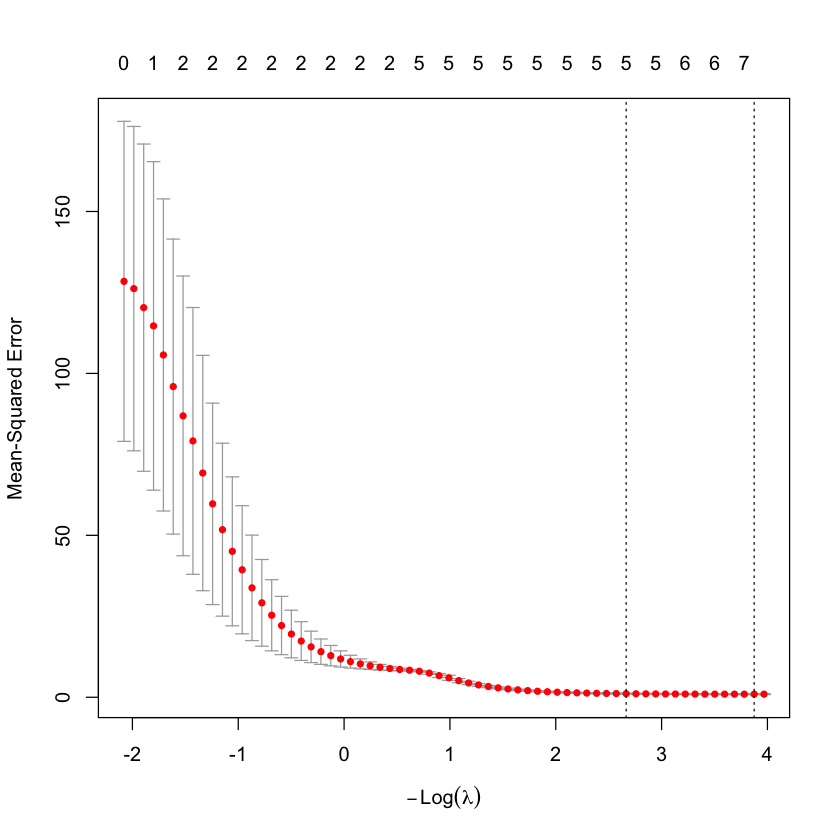

In [ ]:
# plot cross validation error vs. lambda
plot(lasso_cv)

**Comment:** The Lasso lambda is quite small (0.02), which indicates little penalty with many predictors kept. The predictors kept are X, X^2, X^3, X^4, X^6, X^8 and X^10. The Lasso result ends up selecting a larger size of model than the forward & backward stepwise method.

* (f) Now generate a response vector $Y$ according to the model and perform forward stepwise selection and the lasso. Discuss the results obtained.

$$
Y=\beta_0+\beta_7 X^7+\epsilon,
$$

In [ ]:
set.seed(123)
# generate beta7
beta7 = runif(1, -10, 10)
print(paste('beta7=', beta7))

# generate Y using the new model
Y = beta0 + beta7*(X**7) + e

# recreate dataframe
data <- data.frame(Y = Y)
for (i in 1:10) {
  data[[paste0("X", i)]] = X^i
}
head(data)

[1] "beta7= -4.24844959750772"


,Y,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,-4.765895,-0.6264538,0.39244438,-0.245848275,0.154012589,-0.0964817733,6.044137e-02,-3.786373e-02,2.371988e-02,-1.485941e-02,9.308733e-03
2,-4.264305,0.1836433,0.03372487,0.006193347,0.001137367,0.0002088698,3.835755e-05,7.044108e-06,1.293603e-06,2.375616e-07,4.362661e-08
3,-4.008598,-0.8356286,0.69827518,-0.583498718,0.487588224,-0.4074426711,3.404708e-01,-2.845071e-01,2.377423e-01,-1.986642e-01,1.660095e-01
4,-115.857948,1.5952808,2.54492084,4.059863355,6.476622070,10.3320308510,1.648249e+01,2.629420e+01,4.194663e+01,6.691666e+01,1.067509e+02
5,-4.962767,0.3295078,0.10857537,0.035776429,0.011788611,0.0038844391,1.279953e-03,4.217544e-04,1.389714e-04,4.579214e-05,1.508887e-05
6,-1.475785,-0.8204684,0.67316837,-0.552313364,0.453155653,-0.3717998868,3.050501e-01,-2.502839e-01,2.053500e-01,-1.684832e-01,1.382352e-01


In [ ]:
# forward stepwise selection
forward_model = regsubsets(Y ~ X1+X2+X3+X4+X5+X6+X7+X8+X9+X10,
                          data = data,
                          nvmax=10,
                          method='forward')

# show model summary
forward_model_summary = summary(forward_model)

# show selected predictors in each model
print('The model result summary is:')
forward_model_summary$which

# model index with the smallest Cp
best_cp_index = which.min(forward_model_summary$cp)

# show the model obtained according to best cp
best_predictors = names(which(forward_model_summary$which[best_cp_index, ]))
print(paste(
  'The predictors obtained according to best cp:',
  paste(names(which(forward_model_summary$which[best_cp_index, ])), collapse = ", ")
))

[1] "The model result summary is:"


,(Intercept),X1,X2,X3,X4,X5,X6,X7,X8,X9,X10
1,TRUE,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,TRUE,FALSE,FALSE,FALSE
2,TRUE,FALSE,TRUE,FALSE,FALSE,FALSE,FALSE,TRUE,FALSE,FALSE,FALSE
3,TRUE,FALSE,TRUE,FALSE,FALSE,TRUE,FALSE,TRUE,FALSE,FALSE,FALSE
4,TRUE,TRUE,TRUE,FALSE,FALSE,TRUE,FALSE,TRUE,FALSE,FALSE,FALSE
5,TRUE,TRUE,TRUE,TRUE,FALSE,TRUE,FALSE,TRUE,FALSE,FALSE,FALSE
6,TRUE,TRUE,TRUE,TRUE,FALSE,TRUE,FALSE,TRUE,TRUE,FALSE,FALSE
7,TRUE,TRUE,TRUE,TRUE,FALSE,TRUE,FALSE,TRUE,TRUE,TRUE,FALSE
8,TRUE,TRUE,TRUE,TRUE,FALSE,TRUE,TRUE,TRUE,TRUE,TRUE,FALSE
9,TRUE,TRUE,TRUE,TRUE,FALSE,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE
10,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE


[1] "The predictors obtained according to best cp: (Intercept), X2, X7"


In [ ]:
# fit linear model using the seleted predictors
model = lm(Y ~ X2+X7, data = data)

# get coefficients
model_coefs = coef(model)
print('Below are coefficients of the model:')
print(model_coefs)


[1] "Below are coefficients of the model:"
(Intercept)          X2          X7 
 -4.2359005  -0.1417084  -4.2468944 


**Comment:** From above, the model selected from the forward stepwise method includes predictor X^2 and X^7 instead of just X^7 as how the model is definedd. However, it is close enough, especially that the coefficient of X^7 variable is same as what was selected.

In [ ]:
library(glmnet)
set.seed(1)  # set seed

# cross-validated Lasso
lasso_cv = cv.glmnet(as.matrix(data[,2:11]), data$Y, alpha = 1, nfolds = 5)

# optimal lambda
lambda_opt = lasso_cv$lambda.min

print(paste('The optimal lambda is:', lambda_opt))

[1] "The optimal lambda is: 7.5047243621755"


In [ ]:
# extract coefficients at optimal lambda
coef(lasso_cv, s= 'lambda.min')

11 x 1 sparse Matrix of class "dgCMatrix"
            lambda.min
(Intercept)  -4.870024
X1            .       
X2            .       
X3            .       
X4            .       
X5            .       
X6            .       
X7           -4.123857
X8            .       
X9            .       
X10           .       

**Comment:** The Lasso result shows the optimal lambda is 7.5, which is medium-low penalty, indicating medium level penalty. The Lasso result keeps only one predictor X^7, and this matches with model, meaning Lasso has very good performance.


**6.3** In this exercise, we will predict the number of applications received using the other variables in the College data set.

* (a) Split the data set into a training set and a test set.


In [ ]:
library(ISLR)
library(caTools)

# load College dataset
data(College)
head(College)

# train test split
set.seed(1)
train_test_split = sample.split(College$Apps, SplitRatio = 0.7)

train = subset(College, train_test_split == TRUE)
test  = subset(College, train_test_split == FALSE)

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15
Albertson College,Yes,587,479,158,38,62,678,41,13500,3335,500,675,67,73,9.4,11,9727,55


* (b) Fit a linear model using least squares on the training set, and report the test error obtained.


In [ ]:
# fit a linear model
lm_fit = lm(Apps ~ ., data = train)

# predict using test dataset
predict = predict(lm_fit, newdata = test)

# calculate mse
mse = mean((test$Apps - predict)^2)

print(paste('Test error obtaines is:', mse))

[1] "Test error obtaines is: 1819252.07410808"


* (c) Fit a ridge regression model on the training set, with $\lambda$ chosen by cross-validation. Report the test error obtained.


In [ ]:
# fit a cv Ridge regression model
x_train = model.matrix(Apps~., train)[,-1]
y_train = train$Apps
x_test = model.matrix(Apps~., test)[,-1]
y_test = test$Apps

set.seed(1)
cv_ridge = cv.glmnet(x_train, y_train, alpha = 0)

# find optimial lambda
opt_lambda = cv_ridge$lambda.min
print(paste('The chosen lambda is:', opt_lambda))

# predict
ridge_pred = predict(cv_ridge, s = opt_lambda, newx = x_test)

# calculate mse
ridge_mse = mean((ridge_pred - y_test)^2)

print(paste('The test error obtained is:', ridge_mse))

[1] "The chosen lambda is: 333.071138526069"
[1] "The test error obtained is: 3235896.48611527"


* (d) Fit a lasso model on the training set, with $\lambda$ chosen by crossvalidation. Report the test error obtained, along with the number of non-zero coefficient estimates.


In [ ]:
# fit a cv Lasso regression model
x_train = model.matrix(Apps~., train)[,-1]
y_train = train$Apps
x_test = model.matrix(Apps~., test)[,-1]
y_test = test$Apps

set.seed(1)
cv_lasso = cv.glmnet(x_train, y_train, alpha = 1, nfolds = 5)

# find optimial lambda
opt_lambda = cv_lasso$lambda.min
print(paste('The chosen lambda is:', opt_lambda))

# predict
lasso_pred = predict(cv_lasso, s = opt_lambda, newx = x_test)

# calculate mse
lasso_mse = mean((lasso_pred - y_test)^2)

print(paste('The test error obtained is:', lasso_mse))

# extract coefficients at optimal lambda
cv_lasso_coef = coef(cv_lasso, s= 'lambda.min')

# non-zero coefficients
non_zero_coefficients = as.matrix(cv_lasso_coef[cv_lasso_coef[,1]!=0,])
colnames(non_zero_coefficients) = 'coefficients'
print('Non zero coefficient estimates are:')
print(non_zero_coefficients)

[1] "The chosen lambda is: 7.8754318070264"
[1] "The test error obtained is: 1900070.52655234"
[1] "Non zero coefficient estimates are:"
             coefficients
(Intercept) -594.16878641
PrivateYes  -631.75878293
Accept         1.19607355
Top10perc     42.27424773
Top25perc    -11.30275141
F.Undergrad    0.05753874
Outstate      -0.01687180
Room.Board     0.13063519
Books          0.04507271
Personal       0.03774271
PhD           -7.01558112
Terminal      -0.74219491
perc.alumni   -6.04188633
Expend         0.06298551
Grad.Rate      7.88844382


* (e) Fit a PCR model on the training set, with $M$ chosen by crossvalidation. Report the test error obtained, along with the value of $M$ selected by cross-validation.


In [ ]:
library(pls)

set.seed(1)
# fit PCR model
pcr_fit = pcr(Apps ~ ., data = train, scale = TRUE, validation = "CV")

# calculate mse
pcr_mse = MSEP(pcr_fit)

# find best M
best_M = which.min(pcr_mse$val[1,1,-1])
print(paste('The best M obtained is:', best_M))

# test error
pcr_pred = predict(pcr_fit, newdata = test, ncomp = best_M)
pcr_mse_test = mean((test$Apps - pcr_pred)^2)
print(paste('The test error is:', pcr_mse_test))


[1] "The best M obtained is: 17"
[1] "The test error is: 1819252.07410808"


* (f) Fit a PLS model on the training set, with $M$ chosen by crossvalidation. Report the test error obtained, along with the value of $M$ selected by cross-validation.

In [ ]:
library(pls)

set.seed(1)

# fit the pls mode
pls_fit = plsr(
  Apps ~ .,
  data = train,
  scale = TRUE,
  validation = "CV"
)

# obtain best M
pls_mse = MSEP(pls_fit)
best_M = which.min(pls_mse$val[1,1,-1])
print(paste('The best M obtained is:', best_M))

# predict on test set
pls_pred = predict(pls_fit, newdata = test, ncomp = best_M)

# test error
pls_test_mse = mean((test$Apps - pls_pred)^2)
print(paste('The test error is:', pls_test_mse))

[1] "The best M obtained is: 11"
[1] "The test error is: 1827868.17818113"


* (g) Comment on the results obtained. How accurately can we predict the number of college applications received? Is there much difference among the test errors resulting from these five approaches?


**Comment:** The results above shows the accuracy of predicting number of college applications is low, as the test error are all big in the five approaches. Among them, the Ridge model performs the worst as all predictors in the dataset are included, while the linear model, PCR and PLS perform relatively better as they signficantly shrink the number of predictors to reduce the overfit and variance.

### Chapter-7

**7.1** Suppose that a curve $\hat{g}$ is computed to smoothly fit a set of $n$ points using the following formula:
$$
\hat{g}=\arg \min _g\left(\sum_{i=1}^n\left(y_i-g\left(x_i\right)\right)^2+\lambda \int\left[g^{(m)}(x)\right]^2 d x\right),
$$

where $g^{(m)}$ represents the $m$ th derivative of $g$ (and $g^{(0)}=g$ ). Provide example sketches of $\hat{g}$ in each of the following scenarios.

* (a) $\lambda=\infty, m=0$.


**Answer:** The $\lambda = \infty$ penalizes any complexity, so that curve is a flat curve (infinite smoothness). $\hat{g} = 0$ minimizes the objective.
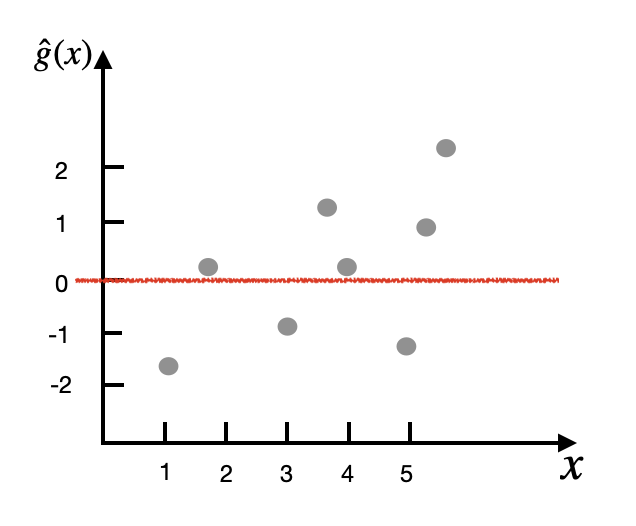

* (b) $\lambda=\infty, m=1$.


**Answer:** $\lambda = \infty$ and $m=1$ require a flat line and zero slope that minimizes the objective
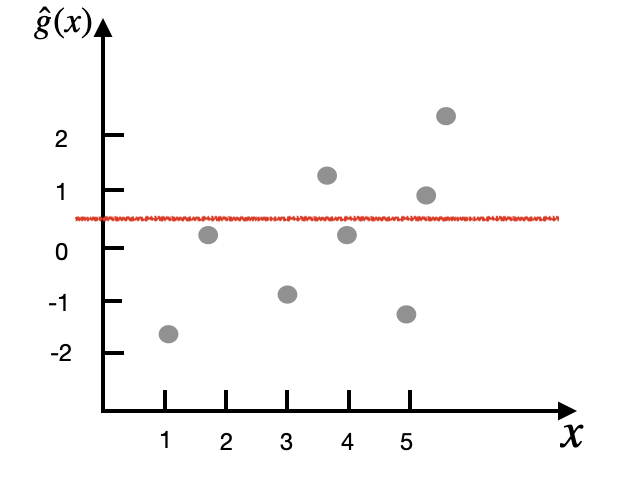

* (c) $\lambda=\infty, m=2$


**Answer:** $\lambda = \infty$ and $m=2$ require a linear line with any slope that minimizes the objective.
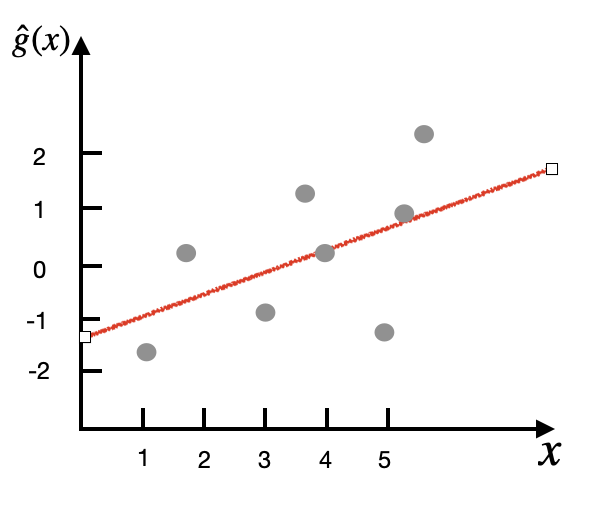

* (d) $\lambda=\infty, m=3$.


**Answer:** $\lambda = \infty$ and $m=3$ require a simple quadratic function curve to minimizes the objective.
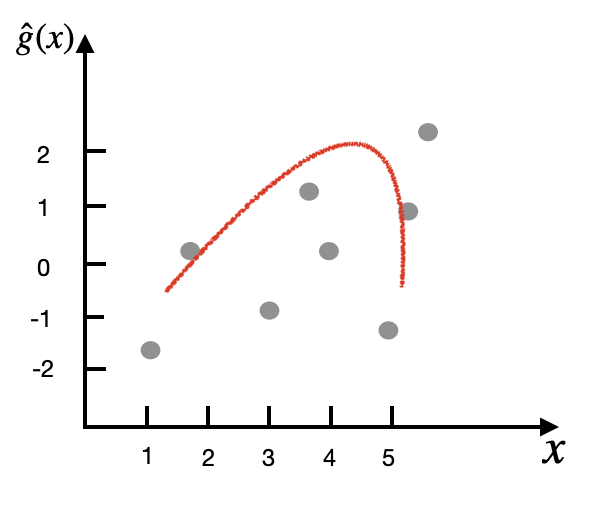

* (e) $\lambda=0, m=3$.

**Answer:** $\lambda = 0$ and $m=3$ allows a very wiggly quadratic function with no smoothness constraints.
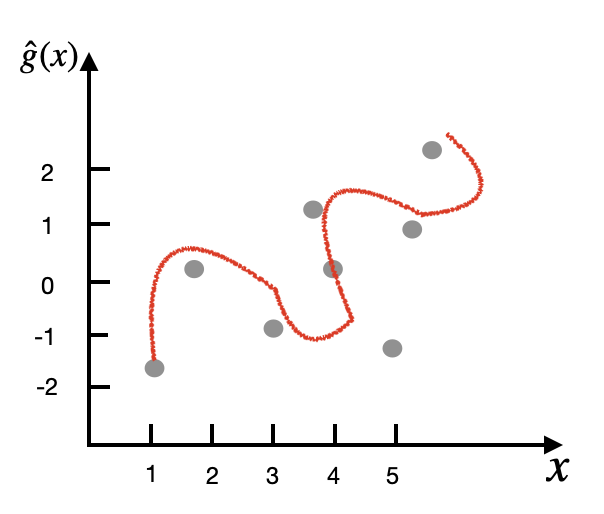

**7.2** Consider two curves, $\hat{g}_1$ and $\hat{g}_2$, defined by
$$
\begin{aligned}
& \hat{g}_1=\arg \min _g\left(\sum_{i=1}^n\left(y_i-g\left(x_i\right)\right)^2+\lambda \int\left[g^{(3)}(x)\right]^2 d x\right), \\
& \hat{g}_2=\arg \min _g\left(\sum_{i=1}^n\left(y_i-g\left(x_i\right)\right)^2+\lambda \int\left[g^{(4)}(x)\right]^2 d x\right),
\end{aligned}
$$

where $g^{(m)}$ represents the $m$ th derivative of $g$.

* (a) As $\lambda \rightarrow \infty$, will $\hat{g}_1$ or $\hat{g}_2$ have the smaller training RSS?

* (b) As $\lambda \rightarrow \infty$, will $\hat{g}_1$ or $\hat{g}_2$ have the smaller test RSS?

* (c) For $\lambda=0$, will $\hat{g}_1$ or $\hat{g}_2$ have the smaller training and test RSS?

**7.3** This question uses the variables dis (the weighted mean of distances to five Boston employment centers) and nox (nitrogen oxides concentration in parts per 10 million) from the Boston data. We will treat dis as the predictor and nox as the response.

* (a) Use the poly() function from the ISLP.models module to fit a cubic polynomial regression to predict nox using dis. Report the regression output, and plot the resulting data and polynomial fits.

In [ ]:
from ISLP import load_data
from ISLP.models import ModelSpec as MS
from ISLP.models import poly
from ISLP.models import summarize
import statsmodels.api as sm

# load Boston data
Boston = load_data('Boston')
Boston.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


In [ ]:
# create a 3-degree polynomial feature X (x, x^2, x^3)
X = MS([poly('dis', degree=3)]).fit_transform(Boston)
y = Boston['nox'] # define y

In [ ]:
# create and fit a regression model
model = sm.OLS(y, X)
results = model.fit()

# show model result
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                    nox   R-squared:                       0.715
Model:                            OLS   Adj. R-squared:                  0.713
Method:                 Least Squares   F-statistic:                     419.3
Date:                Tue, 10 Mar 2026   Prob (F-statistic):          2.71e-136
Time:                        19:44:42   Log-Likelihood:                 690.44
No. Observations:                 506   AIC:                            -1373.
Df Residuals:                     502   BIC:                            -1356.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
intercept                  0

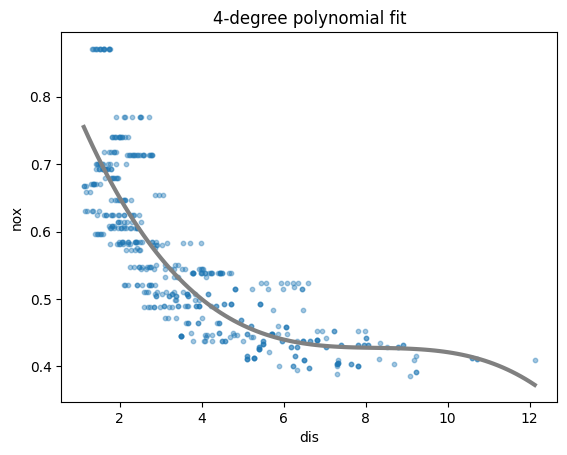

In [ ]:
# create a smooth vector of dis for plot purpose
dis_grid = np.linspace(Boston['dis'].min(), Boston['dis'].max(), 100)

# create polynomial grid based on the dis_grid generated above
X_pred = MS([poly('dis', degree=3)]).fit(Boston).transform(
    pd.DataFrame({'dis': dis_grid})
)

# pred y using the generated polynomial X
y_pred = results.predict(X_pred)

# plot the data x and y in Boston
plt.scatter(Boston['dis'], y, s=10, alpha=0.4) # plot dis vs. nox
# add the fitted y_pred vs. x_pred on the plot
plt.plot(dis_grid, y_pred, color='grey', linewidth=3)

plt.xlabel("dis")
plt.ylabel("nox")
plt.title('4-degree polynomial fit')
plt.show()

* (b) Plot the polynomial fits for a range of different polynomial degrees (say, from 1 to 10), and report the associated residual sum of squares.

In [ ]:
rss = [] # create empty vector to store rss

# create a smooth vector of dis grid
dis_grid = np.linspace(Boston['dis'].min(), Boston['dis'].max(), 100)

for d in range(1,11):
  # create a d-degree polynomial feature X
  X = MS([poly('dis', degree=d)]).fit_transform(Boston)
  y = Boston['nox'] # define y

  # create and fit a regression model
  model = sm.OLS(y, X).fit()

  rss.append(np.sum(model.resid**2))

rss_df = pd.DataFrame({'rss': rss, 'degree':range(1,11)})
print(rss_df)

        rss  degree
0  2.768563       1
1  2.035262       2
2  1.934107       3
3  1.932981       4
4  1.915290       5
5  1.878257       6
6  1.849484       7
7  1.835630       8
8  1.833331       9
9  1.832171      10


Text(0.5, 1.0, 'RSS by Polynomial Degrees')

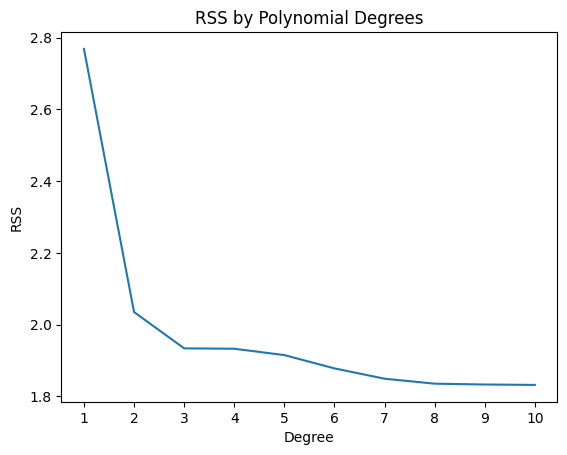

In [ ]:
# plot rss vs. degree

plt.plot(rss_df['degree'], rss_df['rss'])
plt.xlabel('Degree')
plt.xticks(range(1,11))
plt.ylabel('RSS')
plt.title('RSS by Polynomial Degrees')


* (c) Perform cross-validation or another approach to select the optimal degree for the polynomial, and explain your results.

In [ ]:
from sklearn.linear_model import LinearRegression
import pandas as pd
from sklearn.model_selection import cross_val_score

cv_mse = [] # create empty vector to store cross validation mse for each model

# cross validation for each degree of model
for d in range(1,11):

  # create a d-degree polynomial feature X
  X = MS([poly('dis', degree=d)]).fit_transform(Boston)
  y = Boston['nox'] # define y

  # cross validation
  neg_mse = cross_val_score(
    LinearRegression(), # define the model
    X,
    y,
    cv=10, # 10 folds
    scoring='neg_mean_squared_error' # output cv error scors
)

  # mean mse of the 10-fold cv for current model
  mean_mse = -neg_mse.mean()

  # save mse
  cv_mse.append(mean_mse)

# cv mse df
print('The cross validation MSE for each model is:')
pd.DataFrame({'degree': range(1,11),
              'cv mse': cv_mse})

The cross validation MSE for each model is:


,degree,cv mse
0,1,0.006100
1,2,0.004437
2,3,0.004223
3,4,0.005732
4,5,0.013495
5,6,0.105670
6,7,0.199544
7,8,1.532568
8,9,0.639701
9,10,41.316411


**Comment:** The cross validation result shows that when degree is 3, the mean squared error is the lowest at 0.004223. The optimal polynomial seleted is a 3-degree polynomial

* (d) Use the bs () function from the ISLP.models module to fit a regression spline to predict nox using dis. Report the output for the fit using four degrees of freedom. How did you choose the knots? Plot the resulting fit.

In [ ]:
from ISLP.models import bs

# create a four degrees of freedom cubic spline basis for dis
X = MS([bs('dis', df=4)]).fit_transform(Boston)
y = Boston['nox'] # define y

# fit regreesion model
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    nox   R-squared:                       0.716
Model:                            OLS   Adj. R-squared:                  0.714
Method:                 Least Squares   F-statistic:                     316.5
Date:                Wed, 11 Mar 2026   Prob (F-statistic):          1.39e-135
Time:                        20:49:58   Log-Likelihood:                 691.93
No. Observations:                 506   AIC:                            -1374.
Df Residuals:                     501   BIC:                            -1353.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
intercept            0.7345      0.015  

In [ ]:
import numpy as np
# create a smooth vector of dis for prediction
dis_grid = np.linspace(Boston['dis'].min(), Boston['dis'].max(), 200)

# build predictions of X using the spline transformations used to build the model
X_pred = MS([bs('dis', df=4)]).fit(Boston).transform(
    pd.DataFrame({'dis': dis_grid})
)

# predict y using the fitted model and the X_pred generated above
y_pred = model.predict(X_pred)

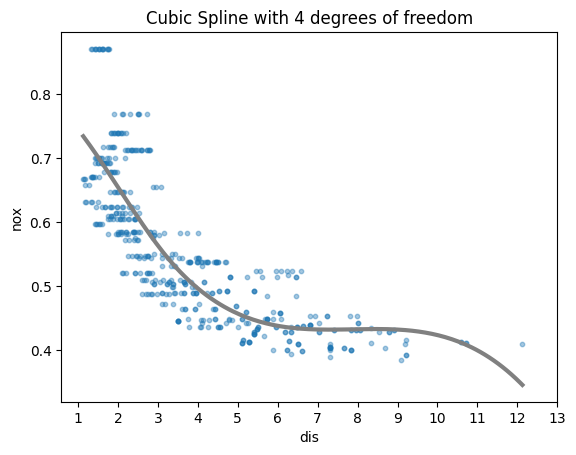

In [ ]:
import matplotlib.pyplot as plt

# plot the resulting fit
plt.scatter(Boston['dis'], y, s=10, alpha=0.4)
plt.plot(dis_grid, y_pred, color='grey', linewidth=3)
plt.xlabel("dis")
plt.ylabel("nox")
plt.title('Cubic Spline with 4 degrees of freedom')
plt.xticks(np.arange(np.floor(Boston['dis'].min()), np.ceil(Boston['dis'].max()) + 1, 1))
plt.show()

In the model, the knot is chosen automatically as 1 internal knot, given the df=4 and degree=3 (cubic). Also, from the scatter plot showing the shape of the original data, drawing a line with placing one knot can best fit the data. More than 1 knot makes the fitted line too wiggly.

* (e) Now fit a regression spline for a range of degrees of freedom, and plot the resulting fits and report the resulting RSS. Describe the results obtained.

In [ ]:
# create an empty vector to store RSS
rss = []

# fit models with different degrees of freedom from 3 to 15
for df in range(3,30):
    X = MS([bs('dis', df=df)]).fit_transform(Boston)

    y = Boston['nox'] # define y

    # fit regression model
    model = sm.OLS(y, X).fit()
    rss.append(model.ssr)

pd.DataFrame({'df':range(3,30), 'rss':rss})


,df,rss
0,3,1.934107
1,4,1.922775
2,5,1.840173
3,6,1.833966
4,7,1.829884
5,8,1.816995
6,9,1.825653
7,10,1.792535
8,11,1.796992
9,12,1.788999


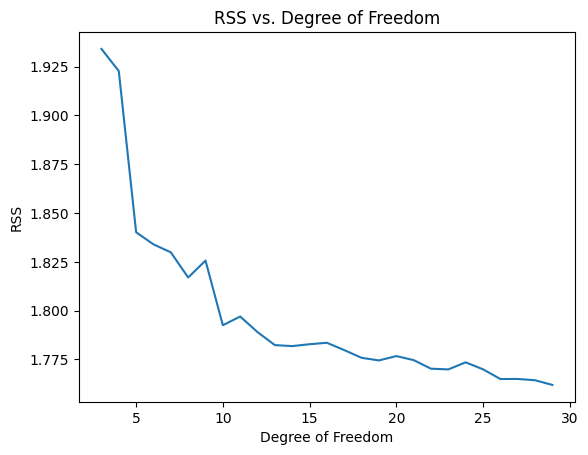

In [ ]:
# plot the resulting rss vs. degree of freedom
plt.plot(range(3,30), rss)
plt.xlabel('Degree of Freedom')
plt.ylabel('RSS')
plt.title('RSS vs. Degree of Freedom')
plt.show()

**Comment:** The results show that RSS declines sharply when the degrees of freedom increase from 4 to 5, with another noticeable drop around 10 degrees of freedom. Beyond 10, RSS continues to decrease, but the improvement becomes gradual and relatively insignificant.

* (f) Perform cross-validation or another approach in order to select the best degrees of freedom for a regression spline on this data. Describe your results.

In [ ]:
from sklearn.model_selection import KFold

# create KFold object for 10-fold cross validation
kf = KFold(n_splits=10, shuffle=True, random_state=1)

cv_mse = [] # create empty vector to store cross validation mse for each df

# cross validation for each df model
for d in range(3,20):

  # create a d-df polynomial feature X
  X = MS([bs('dis', df=d)]).fit_transform(Boston)
  y = Boston['nox'] # define y

  # cross validation
  neg_mse = cross_val_score(
    LinearRegression(), # define the model
    X,
    y,
    cv=kf, # k folds split that is defined above
    scoring='neg_mean_squared_error' # output cv error scors
)

  # mean mse of the 10-fold cv for current model
  mean_mse = -neg_mse.mean()

  # save mse
  cv_mse.append(mean_mse)

# cv mse df
print('The cross validation MSE for each model is:')
pd.DataFrame({'degree of freedom': range(3,20),
              'cv mse': cv_mse})

The cross validation MSE for each model is:


,degree of freedom,cv mse
0,3,0.003870
1,4,0.003885
2,5,0.003709
3,6,0.003718
4,7,0.003725
5,8,0.003716
6,9,0.003759
7,10,0.003714
8,11,0.003736
9,12,0.003725


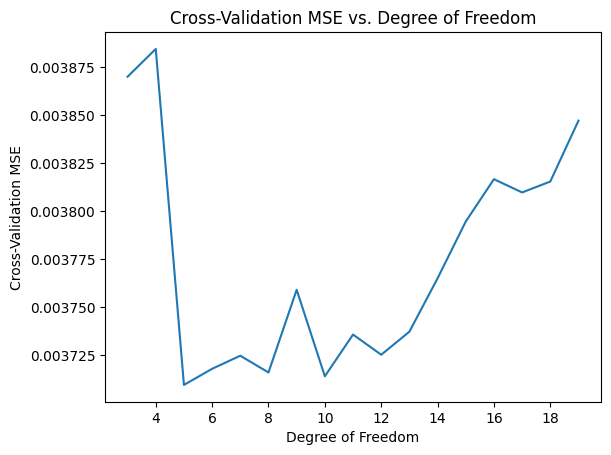

In [ ]:
# plot the cv mse vs. degree of freedom
plt.plot(range(3,20), cv_mse)
plt.xlabel('Degree of Freedom')
plt.ylabel('Cross-Validation MSE')
plt.title('Cross-Validation MSE vs. Degree of Freedom')
plt.show()

**Comment:** The plot shows that the cross-validation MSE is very small (~0.0037–0.00388) and the differences across degrees of freedom (df 3–19) are tiny. At low df spline (df=3–5) can already capture most of the data pattern. Adding more flexibility (higher df) doesn’t improve prediction much. The reason the mse is very tiny is due to the strong relationship between dis and nox, so the spline of dis captures the pattern very well at all degree of freedoms. Although small improvement, the mse optimizes at 5 df, which lines up with the result from RSS analyzed above. So, 5 degree of freedom is the optimal.

**7.4.** This question relates to the College data set.

* (a) Split the data into a training set and a test set. Using out-of-state tuition as the response and the other variables as the predictors, perform forward stepwise selection on the training set in order to identify a satisfactory model that uses just a subset of the predictors.

In [ ]:
install.packages("leaps")

In [ ]:
library(leaps)
library(ISLR)
data("College")
head(College)

# split data into train and test
set.seed(1)

# generate train test split
train_index = sample(1:nrow(College), nrow(College)*0.7) # train index
train = College[train_index,]
test = College[-train_index,]

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15
Albertson College,Yes,587,479,158,38,62,678,41,13500,3335,500,675,67,73,9.4,11,9727,55


In [ ]:
# fit a full model with all variables as predictors on training set
regfit.fwd=regsubsets(Outstate~.,data=train,nvmax=17,method="forward")

# print model summary
reg.summary = summary(regfit.fwd)
print(reg.summary)


Subset selection object
Call: regsubsets.formula(Outstate ~ ., data = train, nvmax = 17, method = "forward")
17 Variables  (and intercept)
            Forced in Forced out
PrivateYes      FALSE      FALSE
Apps            FALSE      FALSE
Accept          FALSE      FALSE
Enroll          FALSE      FALSE
Top10perc       FALSE      FALSE
Top25perc       FALSE      FALSE
F.Undergrad     FALSE      FALSE
P.Undergrad     FALSE      FALSE
Room.Board      FALSE      FALSE
Books           FALSE      FALSE
Personal        FALSE      FALSE
PhD             FALSE      FALSE
Terminal        FALSE      FALSE
S.F.Ratio       FALSE      FALSE
perc.alumni     FALSE      FALSE
Expend          FALSE      FALSE
Grad.Rate       FALSE      FALSE
1 subsets of each size up to 17
Selection Algorithm: forward
          PrivateYes Apps Accept Enroll Top10perc Top25perc F.Undergrad
1  ( 1 )  " "        " "  " "    " "    " "       " "       " "        
2  ( 1 )  "*"        " "  " "    " "    " "       " "       " 

[1] "optimal feature subset-size according to adjr2:"
[2] "13"                                             


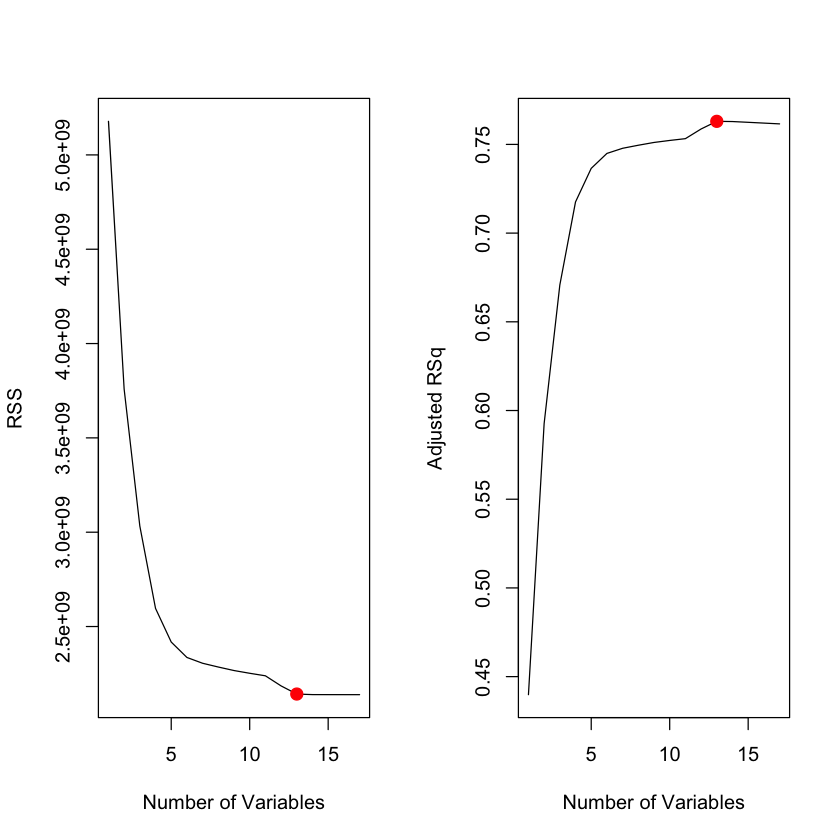

In [13]:
# plot adjr2 by model subset size to determine the optimal feature subset size
par(mfrow=c(1,2))

# get the index (m) of the maximum adjusted R-squared value
m=which.max(reg.summary$adjr2);
print(c("optimal feature subset-size according to adjr2:",m))

# plot rss against the number of variables
plot(reg.summary$rss,xlab="Number of Variables",ylab="RSS",type="l")
points(m,reg.summary$rss[m], col="red",cex=2,pch=20)

# plot adj-r2 against the number of variables
plot(reg.summary$adjr2,xlab="Number of Variables",ylab="Adjusted RSq",type="l")
points(m,reg.summary$adjr2[m], col="red",cex=2,pch=20)

[1] "optimal feature subset-size according to BIC:"
[2] "13"                                           


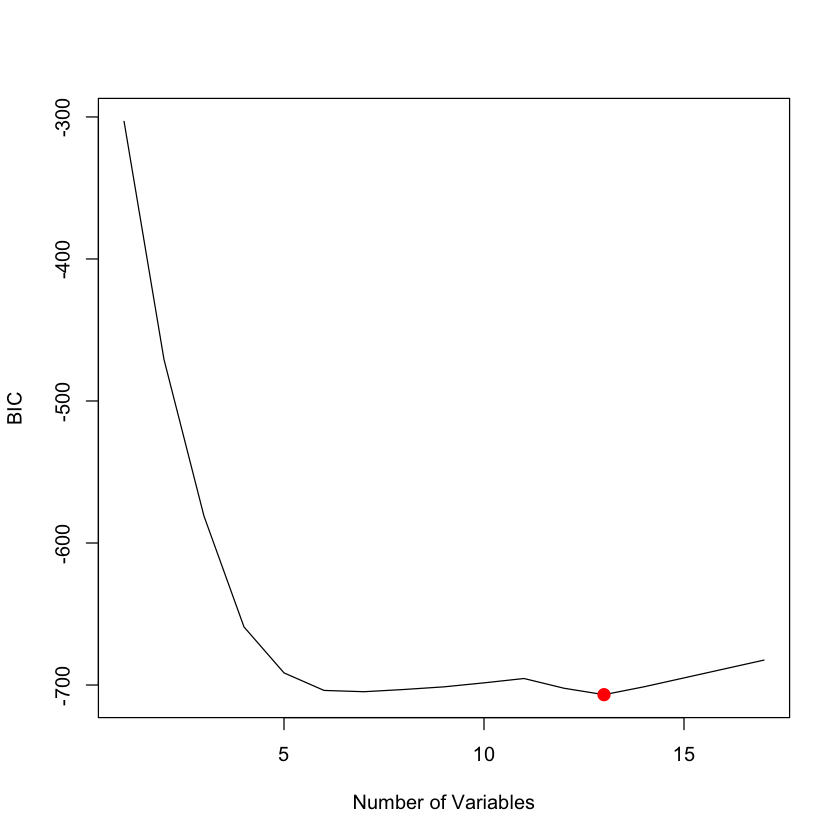

In [41]:
# plot the feature subset size by BIC
m=which.min(reg.summary$bic) # subset with lowest BIC
print(c("optimal feature subset-size according to BIC:",m))
plot(reg.summary$bic,xlab="Number of Variables",ylab="BIC",type='l')
points(m,reg.summary$bic[m],col="red",cex=2,pch=20)

**Comment**: The adjusted R-squared and BIC plots both shows the optimal subset size is 13 predictors. The predictors are Private, Apps, Accept,Top10perc, F.Undergrad,Room.Board, Personal, PhD, Terminal, S.F.Ratio, perc.alumni, Expend, Grad.Rate.

* (b) Fit a GAM on the training data, using out-of-state tuition as the response and the features selected in the previous step as the predictors. Plot the results, and explain your findings.

In [ ]:
# fit GAM model
library(gam)
gam_model <- gam(Outstate ~ Private + s(Apps) + s(Accept) +  s(Top10perc) + s(F.Undergrad) + s(Personal) + s(Room.Board)
                          + s(PhD) + s(Terminal) + s(S.F.Ratio) + s(perc.alumni) + s(Expend) + s(Grad.Rate),
                          data = train)
summary(gam_model)


Call: gam(formula = Outstate ~ Private + s(Apps) + s(Accept) + s(Top10perc) + 
    s(F.Undergrad) + s(Personal) + s(Room.Board) + s(PhD) + s(Terminal) + 
    s(S.F.Ratio) + s(perc.alumni) + s(Expend) + s(Grad.Rate), 
    data = train)
Deviance Residuals:
     Min       1Q   Median       3Q      Max 
-5910.22 -1088.99    73.01  1113.20  7156.97 

(Dispersion Parameter for gaussian family taken to be 3195196)

    Null Deviance: 9260683704 on 542 degrees of freedom
Residual Deviance: 1575229727 on 492.9994 degrees of freedom
AIC: 9723.111 

Number of Local Scoring Iterations: NA 

Anova for Parametric Effects
                Df     Sum Sq    Mean Sq  F value    Pr(>F)    
Private          1 2531384590 2531384590 792.2471 < 2.2e-16 ***
s(Apps)          1  920829380  920829380 288.1918 < 2.2e-16 ***
s(Accept)        1  111647479  111647479  34.9423 6.346e-09 ***
s(Top10perc)     1 1058267438 1058267438 331.2058 < 2.2e-16 ***
s(F.Undergrad)   1  273900889  273900889  85.7227 < 2.2e-16 ***


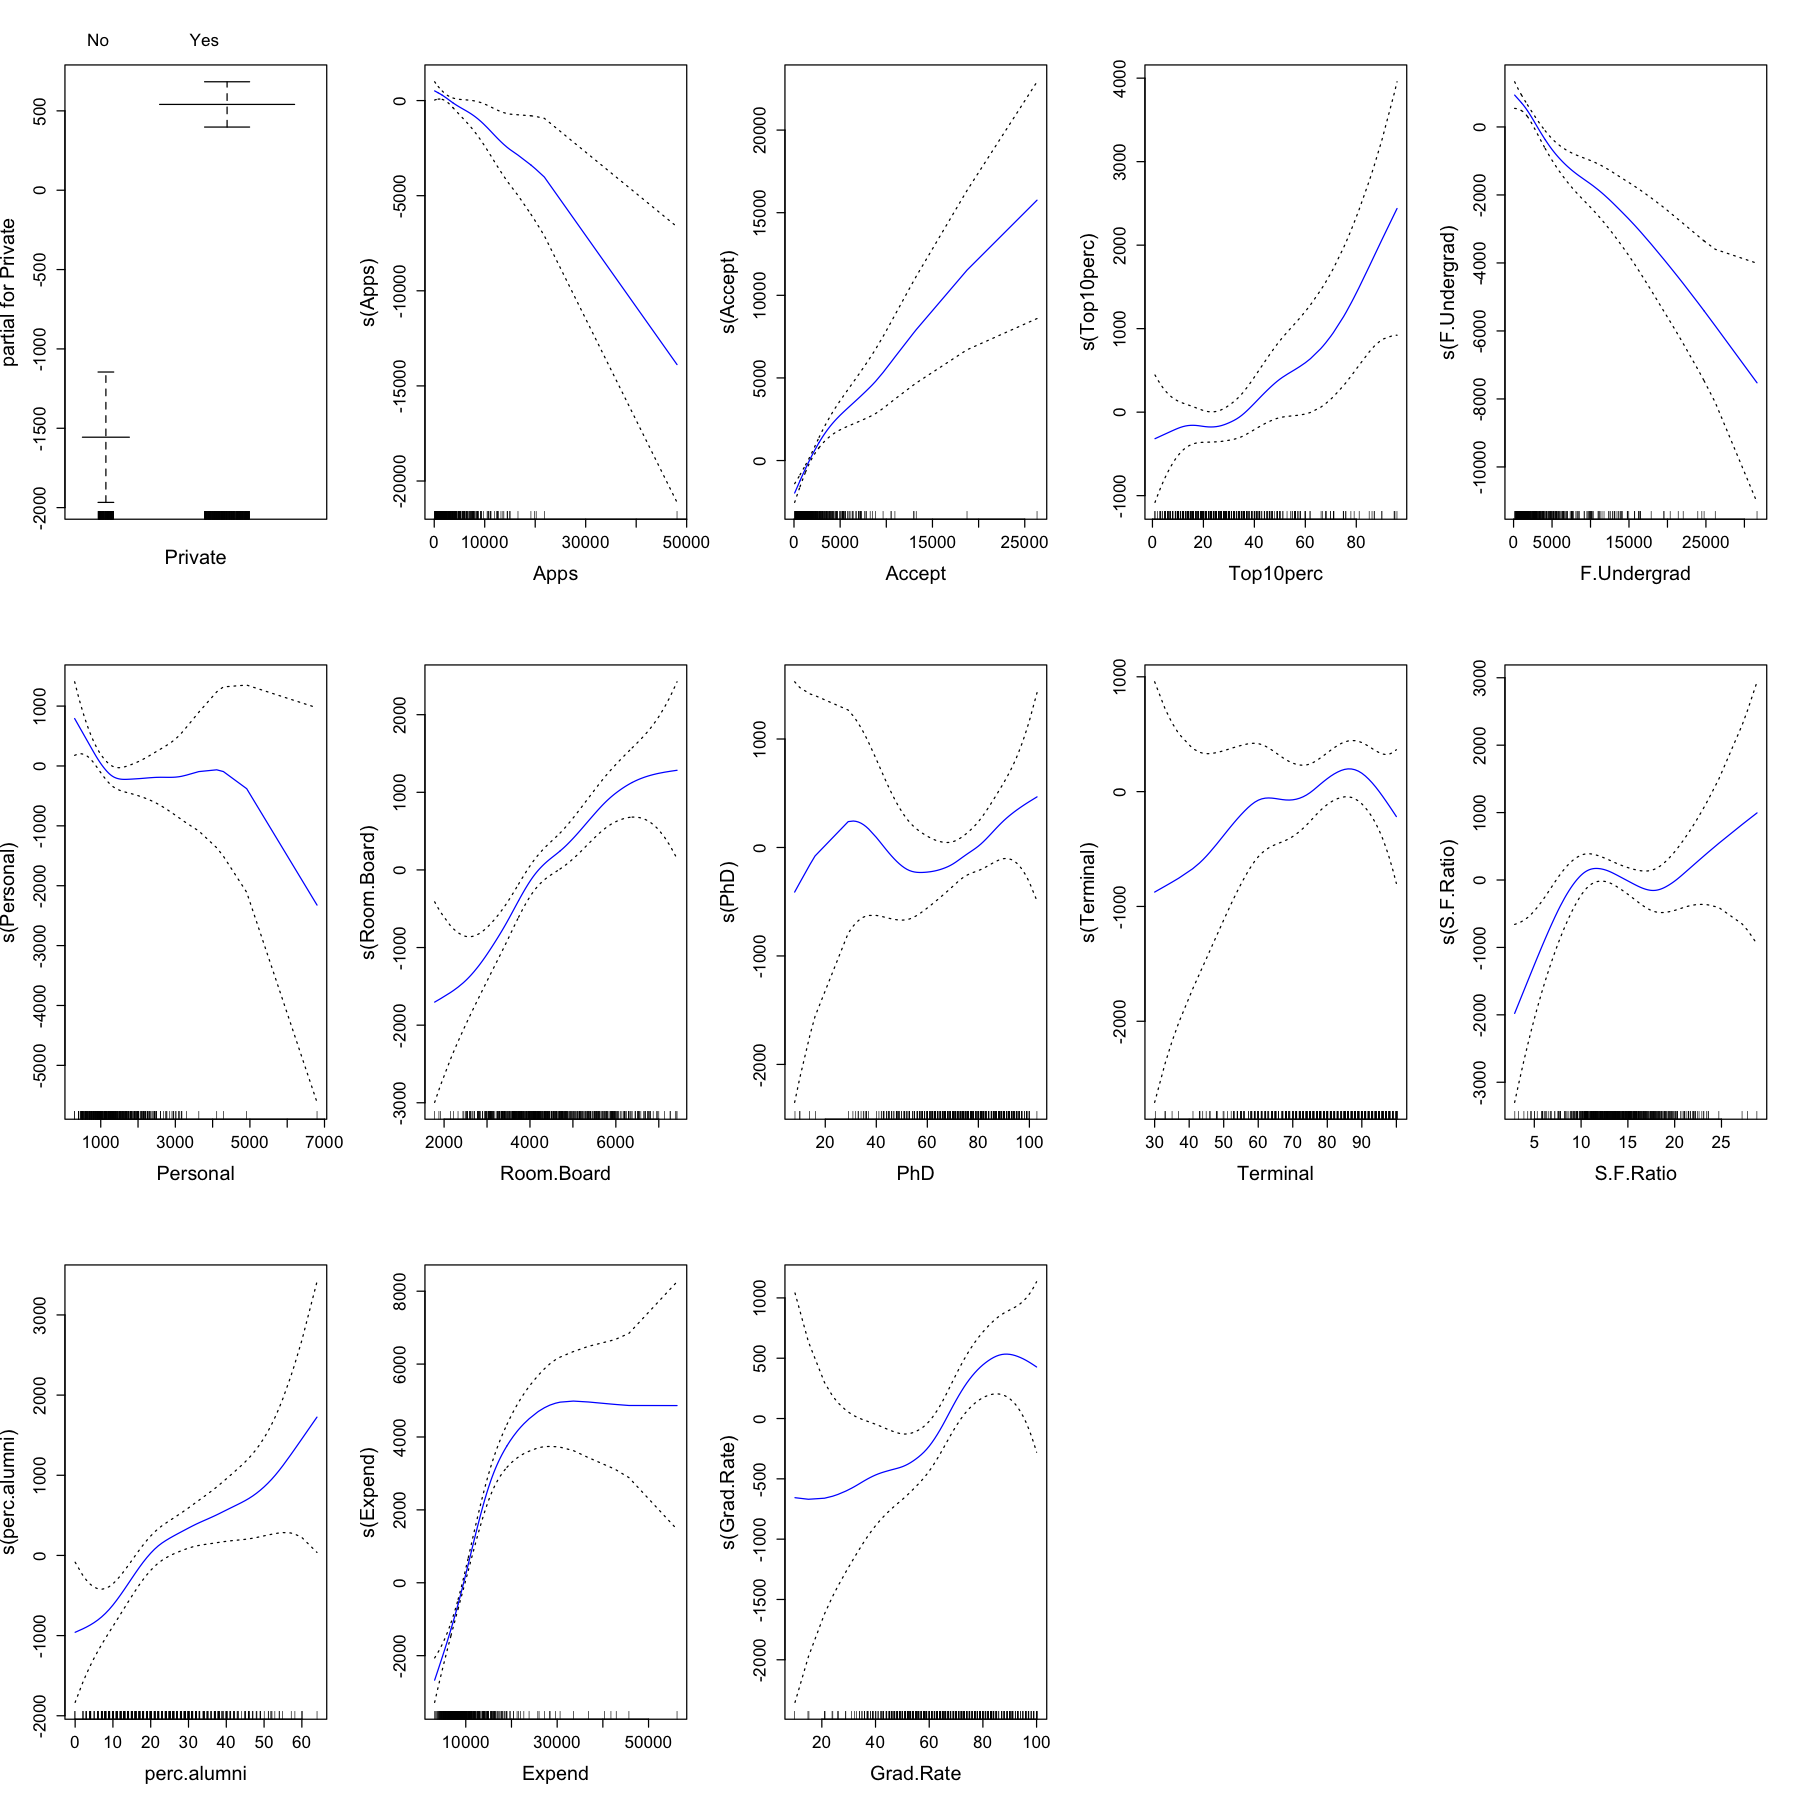

In [54]:
# plot the GAM model

options(repr.plot.width = 15, repr.plot.height = 15)
par(mfrow = c(3,5),
    cex.axis = 1.3,
    cex.lab  = 1.5,
    cex.main = 1.5)
plot(gam_model, se = TRUE, col = "blue")

**Comment:** The model result shows that all these 13 variables have significant effects. The plot and the non-parametric effects significance values suggest that variables with clear non-linear effects on Outstate tuition include Accept, Personal, S.F Ratio, and Expand. Whil other predictors appear to have mostly linear relationships with Outstate tuition. 

* (c) Evaluate the model obtained on the test set, and explain the results obtained.

In [70]:
# make predictions
predictions = predict(gam_model, test)

# calculate rmse
rmse = sqrt(mean((test$Outstate - predictions)**2))

# calculate r^2
r_squared = 1 - sum((test$Outstate - predictions)^2) / sum((test$Outstate - mean(test$Outstate))^2)

# calculate Outstate tuition range, sd and mean
outstate_mean = mean(test$Outstate)
outstate_range = range(test$Outstate)
outstate_sd = sd(test$Outstate)

print(paste('Prediction RMSE on the test model is:', round(rmse,0)))
rmse/outstate_mean
print(paste('The test data Outstate standard deviation is:', round(outstate_sd,0)))
print(paste('The test data Outstate mean is:', round(outstate_mean,0)))
print(paste('Prediction R-squared on the test model is:', round(r_squared,2)))

[1] "Prediction RMSE on the test model is: 1774"


[1] 0.1775877

[1] "The test data Outstate standard deviation is: 3723"
[1] "The test data Outstate mean is: 9988"
[1] "Prediction R-squared on the test model is: 0.77"


**Comment:** Given that the average Outstate in the test data is 9,998; the SD is 3,723; the RMSE is 1,774 which corresponds to a roughly 18% of the error. The RMSE is smaller than the standard deviation, and the R-squared is 77%. These metrics indicate that the model captures meaningful patterns of the data with moderately accurate predictions.

* (d) For which variables, if any, is there evidence of a non-linear relationship with the response?

**Comment:** As explained in (b), Accept, Personal, S.F Ratio, and Expand show non-linear relationship with the response.